### Importar librerias

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

### Cargar datos

In [2]:
sns.set_theme(style="whitegrid")

DATA_PATH = Path("../Data/2026-07-06_bank_dataset_transformed.csv")
CLUSTERED_PATH = Path("../Data/2026-07-06_bank_dataset_clustered.csv")

df = pd.read_csv(CLUSTERED_PATH)

df.shape

(10975, 30)

In [ ]:

df[["segment", "segment_label"]].drop_duplicates()

,segment,segment_label
0,Cluster_0,Adults consolidats
2,Cluster_1,Treballadors manuals
5,Cluster_2,Professionals estudis superiors
7,Retired,Jubilats
9,Cluster_3,Joves solters
162,Student,Estudiants


In [ ]:
# comprobar cluster

print(df.columns.tolist())

['id', 'age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit', 'no_previous_contact', 'had_previous_contact', 'age_group', 'financial_burden', 'financial_burden_label', 'education_rank', 'education_label', 'job_profile', 'week_of_month', 'campaign_group', 'segment', 'segment_label']


In [6]:
# Dataset dimensions
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

# Variable types
display(df.dtypes)

# First observations
display(df.head())

Rows: 10975
Columns: 30


id                          int64
age                       float64
job                           str
marital                       str
education                     str
default                       str
balance                     int64
housing                       str
loan                          str
contact                       str
day                         int64
month                         str
duration                    int64
campaign                    int64
pdays                       int64
previous                    int64
poutcome                      str
deposit                     int64
no_previous_contact         int64
had_previous_contact        int64
age_group                     str
financial_burden            int64
financial_burden_label        str
education_rank            float64
education_label               str
job_profile                   str
week_of_month               int64
campaign_group                str
segment                       str
segment_label 

,id,age,job,marital,education,default,balance,housing,loan,contact,...,age_group,financial_burden,financial_burden_label,education_rank,education_label,job_profile,week_of_month,campaign_group,segment,segment_label
0,1,59.0,admin.,married,secondary,no,2343,yes,no,unknown,...,Middle-Aged (51-65),1,Low burden,2.0,Secondary,White Collar,1,0-3,Cluster_0,Adults consolidats
1,2,56.0,admin.,married,secondary,no,45,no,no,unknown,...,Middle-Aged (51-65),0,No burden,2.0,Secondary,White Collar,1,0-3,Cluster_0,Adults consolidats
2,3,41.0,technician,married,secondary,no,1270,yes,no,unknown,...,Adult (36-50),1,Low burden,2.0,Secondary,White Collar,1,0-3,Cluster_1,Treballadors manuals
3,4,55.0,services,married,secondary,no,2476,yes,no,unknown,...,Middle-Aged (51-65),1,Low burden,2.0,Secondary,Blue Collar,1,0-3,Cluster_0,Adults consolidats
4,5,54.0,admin.,married,tertiary,no,184,no,no,unknown,...,Middle-Aged (51-65),0,No burden,3.0,Tertiary,White Collar,1,0-3,Cluster_0,Adults consolidats


### Distribución segmentos

,Segmento,Clientes,Porcentaje (%),Etiqueta
0,Joves solters,2701,24.6,Joves solters\nn=2.701
1,Adults consolidats,2645,24.1,Adults consolidats\nn=2.645
2,Treballadors manuals,2292,20.9,Treballadors manuals\nn=2.292
3,Professionals estudis superiors,2210,20.1,Professionals estudis superiors\nn=2.210
4,Jubilats,769,7.0,Jubilats\nn=769
5,Estudiants,358,3.3,Estudiants\nn=358


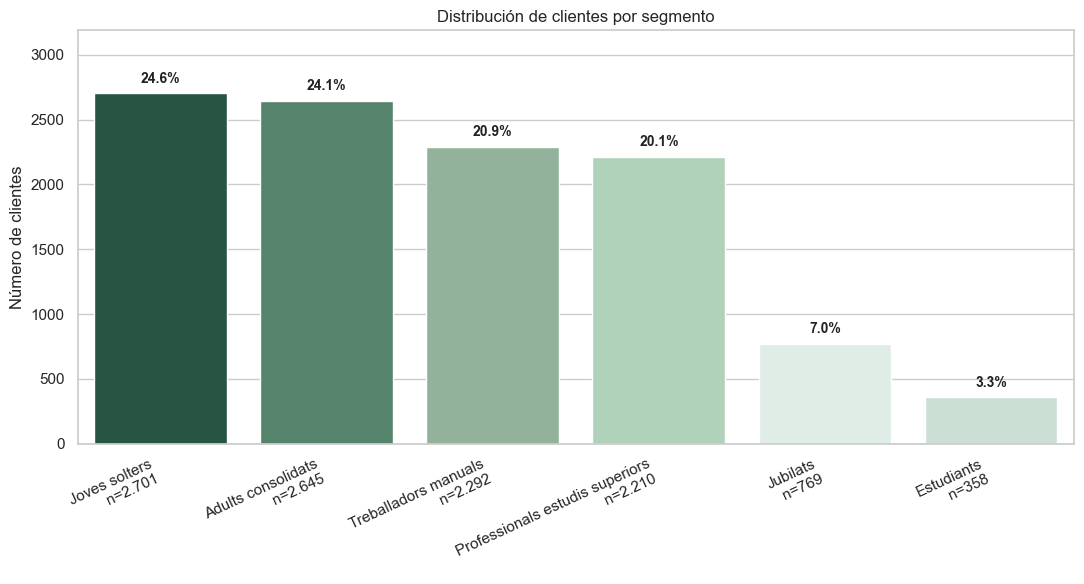

In [16]:
orden_segmentos = df["segment_label"].value_counts().index

segmentos = (
    df["segment_label"]
    .value_counts()
    .rename_axis("Segmento")
    .reset_index(name="Clientes")
)

segmentos["Porcentaje (%)"] = (
    segmentos["Clientes"] / segmentos["Clientes"].sum() * 100
).round(1)

segmentos["Etiqueta"] = [
    f"{seg}\nn={n:,}".replace(",", ".")
    for seg, n in zip(segmentos["Segmento"], segmentos["Clientes"])
]

display(segmentos)

colors = ["#1F5C45", "#4F8A6A", "#8DB79A", "#AAD7B8", "#DDEFE6", "#C8E2D5"]

palette = sns.blend_palette(
    colors,
    n_colors=segmentos.shape[0]
)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=segmentos,
    x="Etiqueta",
    y="Clientes",
    hue="Etiqueta",
    palette=palette,
    legend=False
)

plt.title("Distribución de clientes por segmento")
plt.xlabel("")
plt.ylabel("Número de clientes")
plt.xticks(rotation=25, ha="right")

# Etiquetas encima de las barras
for i, row in segmentos.set_index("Segmento").loc[orden_segmentos].reset_index().iterrows():
    ax.text(
        i,
        row["Clientes"] + 60,
        f'{row["Porcentaje (%)"]:.1f}%',
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="#222222"
    )

# Dar espacio arriba para que las etiquetas no se corten
ax.set_ylim(0, segmentos["Clientes"].max() * 1.18)

plt.tight_layout()
plt.show()

La distribución de clientes por segmento muestra cuatro grupos principales con tamaños similares, entre el 20,1 % y el 24,6 % del total. Los segmentos de jubilados y estudiantes son más pequeños, pero se mantienen separados por su comportamiento diferencial observado previamente. Esta distribución permite comparar el comportamiento financiero entre perfiles sin que un único segmento domine el análisis.

### Analisis variables financieras

In [ ]:
# función reutilizable numeric

def analyze_numeric_by_segment(df, variable, segment_col="segment_label"):
    """
    Analiza una variable numérica por segmento.
    Genera una tabla resumen y un gráfico de barras con la mediana.
    """

    summary = (
        df.groupby(segment_col, observed=True)[variable]
          .agg(
              n_clients="count",
              mean="mean",
              median="median",
              std="std",
              min="min",
              max="max"
          )
          .round(2)
          .sort_values("median", ascending=False)
    )

    display(summary)

    summary["label"] = [
        f"{segment}\nn={n:,}".replace(",", ".")
        for segment, n in zip(summary.index, summary["n_clients"])
    ]

    colors = ["#1F5C45", "#4F8A6A", "#8DB79A", "#AAD7B8", "#DDEFE6", "#C8E2D5"]

    palette = sns.blend_palette(
        colors,
        n_colors=summary.shape[0]
    )

    plot_data = summary.reset_index()

    plt.figure(figsize=(11, 6))

    ax = sns.barplot(
        data=plot_data,
        x="label",
        y="median",
        hue="label",
        palette=palette,
        legend=False,
        width=0.8,
        dodge=False
    )

    for index, row in plot_data.iterrows():
        ax.text(
            x=index,
            y=row["median"] + (plot_data["median"].max() * 0.03),
            s=f'{row["median"]:,.0f} €'.replace(",", "."),
            ha="center",
            va="bottom",
            fontsize=10,
            color="#1F2D26",
            fontweight="bold"
        )

    plt.title(f"Mediana de {variable.replace('_', ' ').title()} por segmento")
    plt.xlabel("Segmento")
    plt.ylabel(f"Mediana de {variable}")
    plt.xticks(rotation=45, ha="right")

    plt.ylim(0, plot_data["median"].max() * 1.18)

    plt.tight_layout()
    plt.show()

In [40]:
# función reutilizable categoric

def analyze_categorical_by_segment(
    df,
    variable,
    segment_col="segment_label",
    order=None,
    highlight_value="yes"
):
    """
    Analiza una variable categórica por segmento.
    Genera tabla de porcentajes y gráfico de barras apiladas con n en el eje X
    y porcentaje destacado encima de cada barra.
    """

    counts = pd.crosstab(df[segment_col], df[variable])
    percentages = (
        pd.crosstab(df[segment_col], df[variable], normalize="index") * 100
    ).round(1)

    if order is not None:
        counts = counts[order]
        percentages = percentages[order]

    segment_n = df[segment_col].value_counts()

    percentages["label"] = [
        f"{segment}\nn={segment_n[segment]:,}".replace(",", ".")
        for segment in percentages.index
    ]

    display(percentages.drop(columns="label"))

    colors = ["#1F5C45", "#4F8A6A", "#8DB79A", "#AAD7B8", "#DDEFE6", "#C8E2D5"]

    palette = sns.blend_palette(
        colors,
        n_colors=percentages.drop(columns="label").shape[1]
    )

    plot_data = percentages.set_index("label")

    ax = plot_data.plot(
        kind="bar",
        stacked=True,
        figsize=(11, 6),
        color=palette,
        width=0.8
    )
    
    ax.grid(False, axis="x")

    # Porcentaje destacado encima de cada barra
    if highlight_value in percentages.columns:
        for i, row in percentages.reset_index().iterrows():
            ax.text(
                x=i,
                y=102,
                s=f'{row[highlight_value]:.1f}%',
                ha="center",
                va="bottom",
                fontsize=10,
                color="#1F2D26",
                fontweight="bold"
            )

    plt.title(f"{variable.replace('_', ' ').title()} por segmento")
    plt.xlabel("Segmento")
    plt.ylabel("Porcentaje (%)")
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, 110)
    plt.legend(
        title=variable.replace("_", " ").title(),
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

#### Balance

,n_clients,mean,median,std,min,max
segment_label,,,,,,
Jubilats,769,2427.64,1097.0,5424.85,-1206,81204
Adults consolidats,2645,1781.78,644.0,3674.44,-6847,66653
Professionals estudis superiors,2210,1639.76,587.0,3193.12,-3058,45248
Estudiants,358,1508.10,497.5,2663.93,0,23878
Treballadors manuals,2292,1198.88,461.5,2401.56,-1701,56831
Joves solters,2701,1259.13,458.0,2543.66,-1139,36252


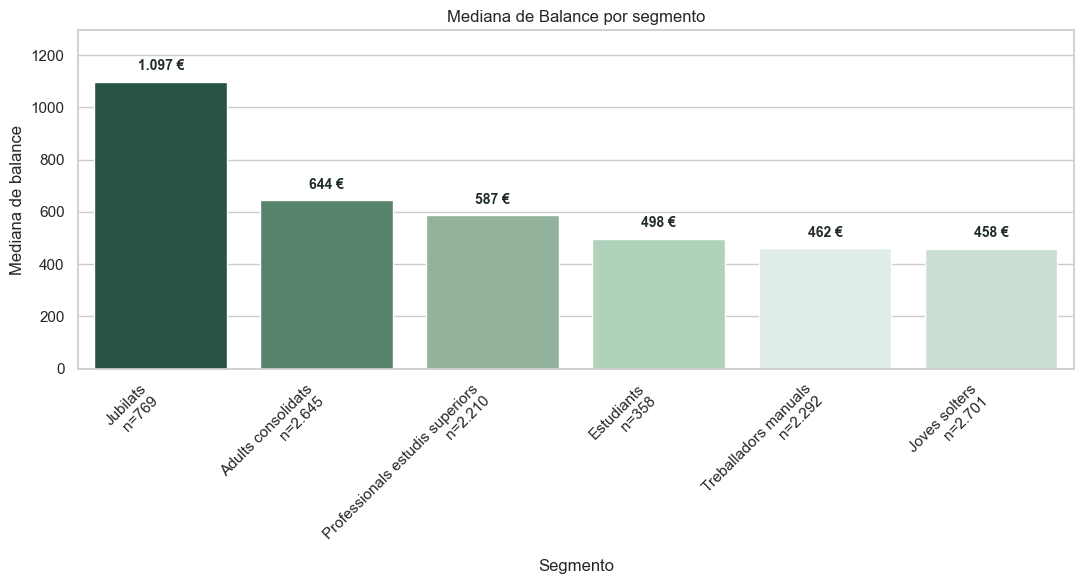

In [27]:
analyze_numeric_by_segment(df, "balance")

Los jubilados presentan la mayor mediana de saldo, mientras que los jóvenes solteros y los trabajadores manuales muestran los niveles más bajos. La diferencia entre medias y medianas confirma una fuerte asimetría provocada por un número reducido de clientes con saldos muy elevados.

#### Housing

housing,no,yes
segment_label,,
Adults consolidats,60.7,39.3
Estudiants,85.8,14.2
Joves solters,48.5,51.5
Jubilats,84.4,15.6
Professionals estudis superiors,52.4,47.6
Treballadors manuals,33.4,66.6


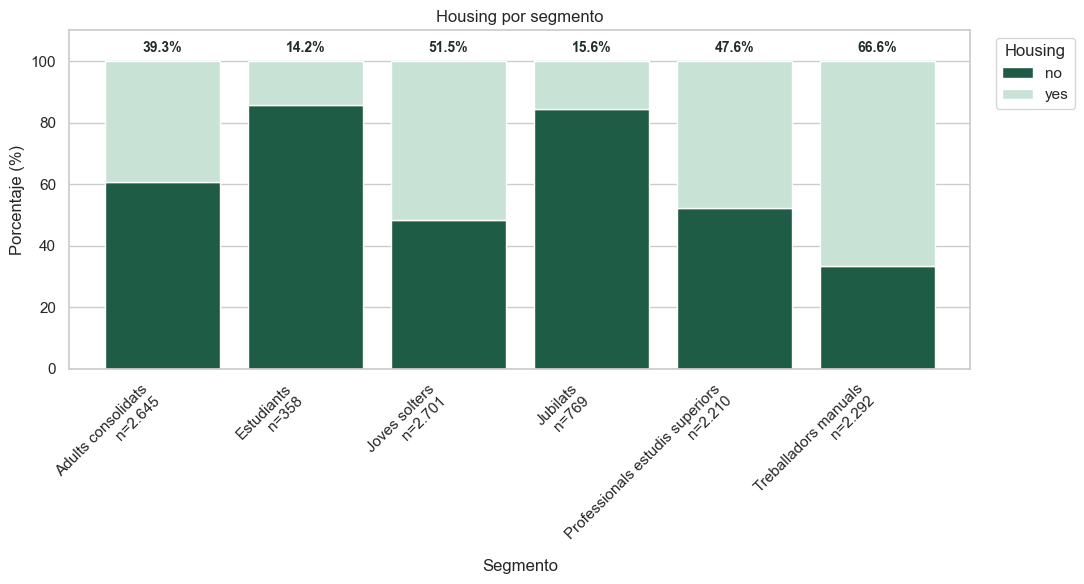

In [41]:
analyze_categorical_by_segment(df, "housing", order=["no", "yes"], highlight_value="yes")

Los trabajadores manuales son el segmento con mayor proporción de hipotecas, seguidos por los jóvenes solteros. En cambio, estudiantes y jubilados apenas presentan financiación hipotecaria, lo que refleja perfiles financieros claramente diferenciados.

#### Loan

loan,no,yes
segment_label,,
Adults consolidats,85.7,14.3
Estudiants,99.7,0.3
Joves solters,86.9,13.1
Jubilats,93.0,7.0
Professionals estudis superiors,88.3,11.7
Treballadors manuals,83.3,16.7


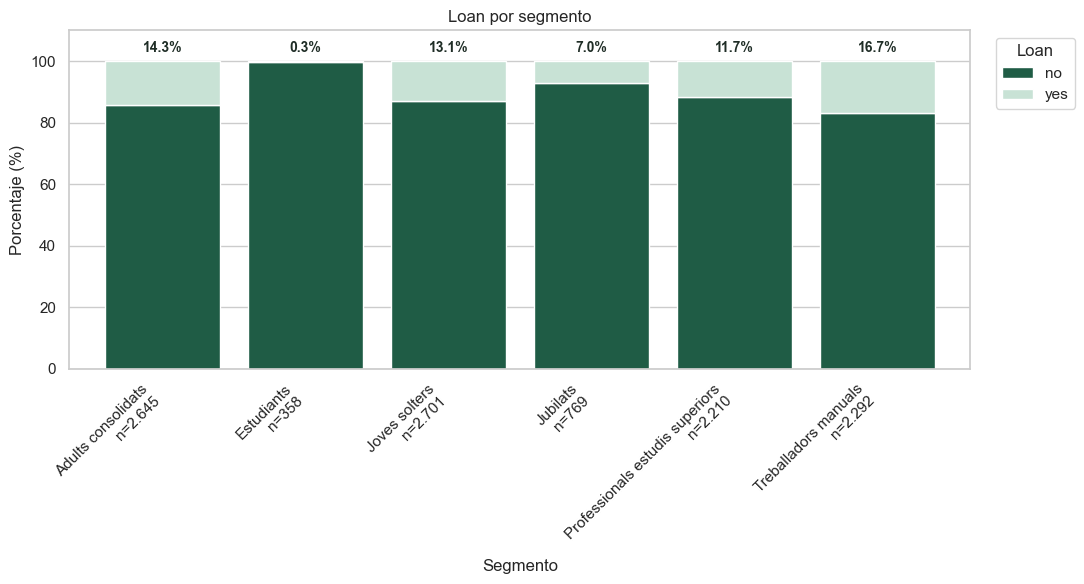

In [42]:
analyze_categorical_by_segment(df, "loan", order=["no", "yes"], highlight_value="yes")

El préstamo personal es poco frecuente en todos los segmentos. Los trabajadores manuales concentran la mayor proporción de clientes con este producto, mientras que los estudiantes prácticamente no recurren a este tipo de financiación.

#### Financial burden

financial_burden_label,High burden,Low burden,No burden
segment_label,,,
Adults consolidats,6.8,39.8,53.3
Estudiants,0.0,14.5,85.5
Joves solters,6.9,50.8,42.3
Jubilats,2.9,16.9,80.2
Professionals estudis superiors,7.2,44.8,47.9
Treballadors manuals,11.7,59.9,28.4


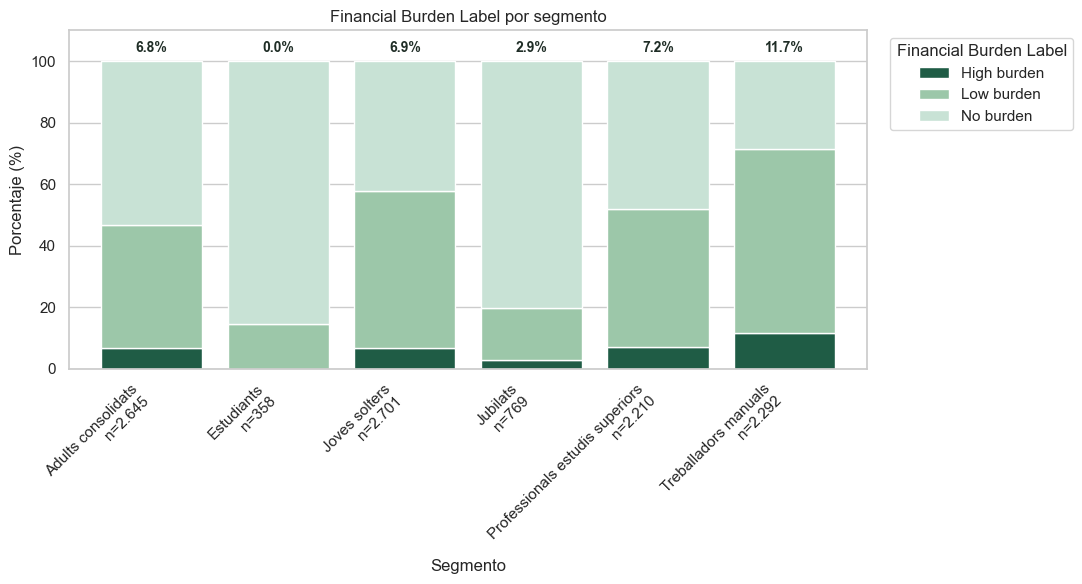

In [43]:
analyze_categorical_by_segment(df, "financial_burden_label", highlight_value="High burden")

La carga financiera varía notablemente entre segmentos. Los trabajadores manuales presentan la mayor proporción de clientes con carga financiera alta o moderada, mientras que jubilados y estudiantes se concentran principalmente en situaciones de baja o nula carga financiera.

#### Default

default,no,yes
segment_label,,
Adults consolidats,98.4,1.6
Estudiants,99.7,0.3
Joves solters,98.3,1.7
Jubilats,99.3,0.7
Professionals estudis superiors,98.7,1.3
Treballadors manuals,98.3,1.7


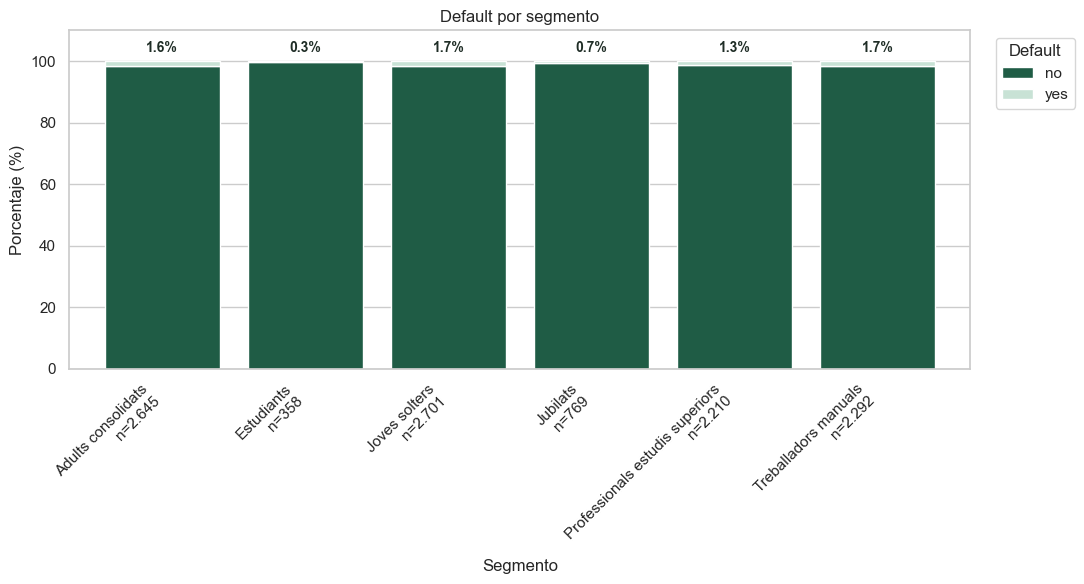

In [44]:
analyze_categorical_by_segment(df, "default", order=["no", "yes"], highlight_value="yes")

El porcentaje de clientes en situación de impago es muy reducido en todos los segmentos y las diferencias observadas son mínimas. Esta variable no parece aportar capacidad de diferenciación entre los perfiles demográficos identificados.

### Resumen del perfil financiero por segmento

In [47]:
perfil = (
    df.groupby("segment_label", observed=True)
      .agg(
          Clientes=("id", "count"),
          Balance_mediana=("balance", "median"),
          Hipoteca_pct=("housing", lambda x: (x == "yes").mean() * 100),
          Prestamo_personal_pct=("loan", lambda x: (x == "yes").mean() * 100),
          Carga_financiera_alta_pct=("financial_burden_label", lambda x: (x == "High burden").mean() * 100),
          Default_pct=("default", lambda x: (x == "yes").mean() * 100)
      )
      .round(1)
)

perfil = perfil.rename(columns={
    "Balance_mediana": "Mediana balance (€)",
    "Hipoteca_pct": "Hipoteca (%)",
    "Prestamo_personal_pct": "Préstamo personal (%)",
    "Carga_financiera_alta_pct": "Carga financiera alta (%)",
    "Default_pct": "Default (%)"
})

display(perfil)

,Clientes,Mediana balance (€),Hipoteca (%),Préstamo personal (%),Carga financiera alta (%),Default (%)
segment_label,,,,,,
Adults consolidats,2645,644.0,39.3,14.3,6.8,1.6
Estudiants,358,497.5,14.2,0.3,0.0,0.3
Joves solters,2701,458.0,51.5,13.1,6.9,1.7
Jubilats,769,1097.0,15.6,7.0,2.9,0.7
Professionals estudis superiors,2210,587.0,47.6,11.7,7.2,1.3
Treballadors manuals,2292,461.5,66.6,16.7,11.7,1.7


- Jubilados presentan el perfil financiero más sólido: tienen la mediana de balance más alta y bajos niveles de endeudamiento (hipoteca, préstamo personal y carga financiera alta)
- Trabajadores manuales muestran la mayor exposición financiera del conjunto. Son el segmento con mayor porcentaje de hipotecas, préstamos personales y carga financiera alta, además de presentar el balance mediano más bajo
- Profesionales con estudios superiores mantienen un balance relativamente elevado, aunque una proporción importante dispone de hipoteca. Su nivel de carga financiera se sitúa en valores intermedios
- Adultos consolidados presentan un perfil equilibrado, con un balance superior a la media de la mayoría de segmentos y niveles moderados de financiación
- Jóvenes solteros poseen el menor patrimonio (mediana de balance) pero una elevada presencia de hipotecas, lo que sugiere una etapa inicial de consolidación financiera
- Estudiantes destacan por una exposición financiera prácticamente nula: muy pocos tienen hipoteca o préstamo personal y no se observan casos con carga financiera alta
- Default registra valores muy bajos en todos los segmentos (inferiores al 2 %), por lo que no parece ser una variable que diferencie claramente los perfiles financieros

### Principales insights

- Los jubilados presentan el perfil financiero más sólido.
- Los trabajadores manuales muestran la mayor exposición financiera.
- Los profesionales con estudios superiores combinan mayor cualificación con balances relativamente elevados.
- Los jóvenes solteros presentan un perfil de entrada al mercado inmobiliario.
- Los estudiantes mantienen la menor exposición financiera.